In [1]:
# Check GPU type
!nvidia-smi

Tue Oct 22 22:06:27 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1050 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P8             N/A / ERR!  |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install ultralytics
!pip -q install  ultralytics

In [3]:
# Import libraries
import pandas as pd
import os
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import cv2
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
import multiprocessing


In [4]:
# check the current working directory
# os.chdir('C:/Users/lamem/OneDrive/Documents/GHD/Microsoft-Learn-Location-Mention-Recognition-Challenge')
os.chdir('C:/Users/abelm/repos/Lacuna-Malaria-Detection-Challenge')
print(os.getcwd())

C:\Users\abelm\repos\Lacuna-Malaria-Detection-Challenge


In [5]:
# Path to where your data is stored
DATA_DIR = Path('./data')

# Preview data files available
os.listdir(DATA_DIR)

['images', 'SampleSubmission.csv', 'Test.csv', 'Train.csv']

In [6]:
# Set up directoris for training a yolo model

# Images directories
DATASET_DIR = Path('datasets/dataset')
IMAGES_DIR = DATASET_DIR / 'images'
TRAIN_IMAGES_DIR = IMAGES_DIR / 'train'
VAL_IMAGES_DIR = IMAGES_DIR / 'val'
TEST_IMAGES_DIR = IMAGES_DIR / 'test'

# Labels directories
LABELS_DIR = DATASET_DIR / 'labels'
TRAIN_LABELS_DIR = LABELS_DIR / 'train'
VAL_LABELS_DIR = LABELS_DIR / 'val'
TEST_LABELS_DIR = LABELS_DIR / 'test'

In [7]:
# Unzip images to 'images' dir
# shutil.unpack_archive(DATA_DIR / 'images.zip', 'images')

In [8]:
# Load train and test files
train = pd.read_csv(DATA_DIR / 'Train.csv')
test = pd.read_csv(DATA_DIR / 'Test.csv')
ss = pd.read_csv(DATA_DIR / 'SampleSubmission.csv')

# Add an image_path column
train['image_path'] = [Path('data/images/' + x) for x in train.Image_ID]
test['image_path'] = [Path('data/images/' + x) for x in test.Image_ID]

# Map str classes to ints (label encoding targets)
train['class_id'] = train['class'].map({'Trophozoite': 0, 'WBC': 1, 'NEG': 2})

# Preview the head of the train set
train.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,image_path,class_id
0,id_u3q6jdck4j.jpg,Trophozoite,1.0,712,1241,737,1270,data\images\id_u3q6jdck4j.jpg,0
1,id_a6cl90trri.jpg,Trophozoite,1.0,558,1566,600,1604,data\images\id_a6cl90trri.jpg,0
2,id_qvc2le9sm8.jpg,Trophozoite,1.0,1317,2788,1448,2914,data\images\id_qvc2le9sm8.jpg,0
3,id_w8xnbd5rvm.jpg,Trophozoite,1.0,925,1744,1041,1823,data\images\id_w8xnbd5rvm.jpg,0
4,id_6dop09rk02.jpg,NEG,1.0,0,0,0,0,data\images\id_6dop09rk02.jpg,2


In [9]:
# Filter out NEG class (Negative images - this images have no Trophozoite nor WBC in them)
# Yolo reccomends that when creating labels for negative images, you leave them empty
# https://github.com/ultralytics/yolov5/issues/3218
# As this is a starter nb, we will ignore the negative images
train = train[~(train['class'] == 'NEG')].reset_index(drop = True)

In [10]:
# Split data into training and validation
train_unique_imgs_df = train.drop_duplicates(subset = ['Image_ID'], ignore_index = True)
X_train, X_val = train_test_split(train_unique_imgs_df, test_size = 0.25, stratify=train_unique_imgs_df['class'], random_state=42)

X_train = train[train.Image_ID.isin(X_train.Image_ID)]
X_val = train[train.Image_ID.isin(X_val.Image_ID)]

# Check shapes of training and validation data
X_train.shape, X_val.shape

((17354, 9), (5488, 9))

In [11]:
# Preview target distribution, seems there a class imbalance that needs to be handled
X_train['class'].value_counts(normalize = True), X_val['class'].value_counts(normalize = True)

(class
 Trophozoite    0.688141
 WBC            0.311859
 Name: proportion, dtype: float64,
 class
 Trophozoite    0.709913
 WBC            0.290087
 Name: proportion, dtype: float64)

In [12]:
# Check if dirs exist, if they do, remove them, otherwise create them.
# This only needs to run once
for DIR in [TRAIN_IMAGES_DIR,VAL_IMAGES_DIR, TEST_IMAGES_DIR, TRAIN_LABELS_DIR,VAL_LABELS_DIR,TEST_LABELS_DIR]:
  if DIR.exists():
    shutil.rmtree(DIR)
  DIR.mkdir(parents=True, exist_ok = True)

In [13]:
# Copy train, val and test images to their respective dirs
for img in tqdm(X_train.image_path.unique()):
  shutil.copy(img, TRAIN_IMAGES_DIR / img.parts[-1])

for img in tqdm(X_val.image_path.unique()):
  shutil.copy(img, VAL_IMAGES_DIR / img.parts[-1])

for img in tqdm(test.image_path.unique()):
  shutil.copy(img, TEST_IMAGES_DIR / img.parts[-1])

  0%|          | 0/1544 [00:00<?, ?it/s]

  0%|          | 0/515 [00:00<?, ?it/s]

  0%|          | 0/1178 [00:00<?, ?it/s]

In [14]:
# Function to convert the bboxes to yolo format and save them
def save_yolo_annotation(row):
    image_path, class_id, output_dir = row['image_path'], row['class_id'], row['output_dir']

    img = cv2.imread(image_path)
    # print image path
    print(image_path)
    if img is None:
        raise ValueError(f"Could not read image from path: {image_path}")

    height, width, _ = img.shape

    label_file = Path(output_dir) / f"{Path(image_path).stem}.txt"

    ymin, xmin, ymax, xmax = row['ymin'], row['xmin'], row['ymax'], row['xmax']

    # Normalize the coordinates
    x_center = (xmin + xmax) / 2 / width
    y_center = (ymin + ymax) / 2 / height
    bbox_width = (xmax - xmin) / width
    bbox_height = (ymax - ymin) / height

    with open(label_file, 'a') as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

In [15]:
X_train.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,image_path,class_id
0,id_u3q6jdck4j.jpg,Trophozoite,1.0,712,1241,737,1270,data\images\id_u3q6jdck4j.jpg,0
2,id_qvc2le9sm8.jpg,Trophozoite,1.0,1317,2788,1448,2914,data\images\id_qvc2le9sm8.jpg,0
3,id_w8xnbd5rvm.jpg,Trophozoite,1.0,925,1744,1041,1823,data\images\id_w8xnbd5rvm.jpg,0
4,id_i7r9hkhxvx.jpg,WBC,1.0,846,906,903,963,data\images\id_i7r9hkhxvx.jpg,1
5,id_fzogq9kijh.jpg,WBC,1.0,641,280,711,373,data\images\id_fzogq9kijh.jpg,1


In [16]:
# Save annotations without parallelization
def process_dataset(dataframe, output_dir):
    dataframe['output_dir'] = output_dir
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        save_yolo_annotation(row)


In [17]:
# Save train and validation labels to their respective dirs
process_dataset(X_train, TRAIN_LABELS_DIR)
process_dataset(X_val, VAL_LABELS_DIR)

C:\Users\abelm\AppData\Local\Temp\ipykernel_14640\3787764289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['output_dir'] = output_dir


  0%|          | 0/17354 [00:00<?, ?it/s]

data\images\id_u3q6jdck4j.jpg
data\images\id_qvc2le9sm8.jpg
data\images\id_w8xnbd5rvm.jpg
data\images\id_i7r9hkhxvx.jpg
data\images\id_fzogq9kijh.jpg
data\images\id_2phbgf1x5m.jpg
data\images\id_8l8zssuabc.jpg
data\images\id_pwiv4czvne.jpg
data\images\id_ylrsd2a6k4.jpg
data\images\id_n0dqkovtp3.jpg
data\images\id_5bbz3srksa.jpg
data\images\id_e3tep47339.jpg
data\images\id_nzkpf8tr8o.jpg
data\images\id_7chz2q4dsm.jpg
data\images\id_9cikz22vmm.jpg
data\images\id_331urb6uko.jpg
data\images\id_vmj225uyxh.jpg
data\images\id_lpc9b0h4yl.jpg
data\images\id_5gudsszz0t.jpg
data\images\id_tmtzoe9bns.jpg
data\images\id_tgqn7f4tx0.jpg
data\images\id_fa626uztwq.jpg
data\images\id_pnave1opt9.jpg
data\images\id_napzy4l85v.jpg
data\images\id_0v91pruf44.jpg
data\images\id_8ztw2t9cet.jpg
data\images\id_r1h52tth8l.jpg
data\images\id_xculy3gzpk.jpg
data\images\id_z0i61ad0tq.jpg
data\images\id_vvcixbrht6.jpg
data\images\id_vtppfsimst.jpg
data\images\id_j0s3jncce7.jpg
data\images\id_xa4qfbdy8x.jpg
data\image

C:\Users\abelm\AppData\Local\Temp\ipykernel_14640\3787764289.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['output_dir'] = output_dir


  0%|          | 0/5488 [00:00<?, ?it/s]

data\images\id_a6cl90trri.jpg
data\images\id_i8qcpi8ey9.jpg
data\images\id_i4d0ulpq39.jpg
data\images\id_8y0uii4k60.jpg
data\images\id_ytq3slqkjm.jpg
data\images\id_a1ladv8a2p.jpg
data\images\id_fvpi1edl84.jpg
data\images\id_6bs4zqzvfr.jpg
data\images\id_7fd9tfijwa.jpg
data\images\id_e20xnaq5qn.jpg
data\images\id_db7urn6j1g.jpg
data\images\id_7fc9zyfy0e.jpg
data\images\id_ytq3slqkjm.jpg
data\images\id_ytq3slqkjm.jpg
data\images\id_glyh3dol96.jpg
data\images\id_6g52lmvz2y.jpg
data\images\id_a6cl90trri.jpg
data\images\id_sillt0ixj9.jpg
data\images\id_58ee05nnpt.jpg
data\images\id_y5sidvg3w2.jpg
data\images\id_0e1cx570oo.jpg
data\images\id_y4hd9yvh59.jpg
data\images\id_okva4xz4nj.jpg
data\images\id_ef0jw5a0zi.jpg
data\images\id_69tmhfv0lu.jpg
data\images\id_55a6sf8hbe.jpg
data\images\id_bu04j7jxbr.jpg
data\images\id_glyh3dol96.jpg
data\images\id_c85ykg3uy2.jpg
data\images\id_et3df5wqcz.jpg
data\images\id_1la6dmk7pp.jpg
data\images\id_pq06urws67.jpg
data\images\id_vdchlkv6hv.jpg
data\image

In [18]:
# Train images dir
TRAIN_IMAGES_DIR

WindowsPath('datasets/dataset/images/train')

In [19]:
# Create a data.yaml file required by yolo
class_names = train['class'].unique().tolist()
num_classes = len(class_names)

data_yaml = {
    'train': '/' + str(TRAIN_IMAGES_DIR),
    'val': '/' + str(VAL_IMAGES_DIR),
    'test': '/' + str(TEST_IMAGES_DIR),
    'nc': num_classes,
    'names': class_names
}

yaml_path = 'data.yaml'
with open(yaml_path, 'w') as file:
    yaml.dump(data_yaml, file, default_flow_style=False)

# Preview data yaml file
data_yaml

{'train': '/datasets\\dataset\\images\\train',
 'val': '/datasets\\dataset\\images\\val',
 'test': '/datasets\\dataset\\images\\test',
 'nc': 2,
 'names': ['Trophozoite', 'WBC']}

Plotting id_0051lznyrt.jpg with 4 bounding boxes.


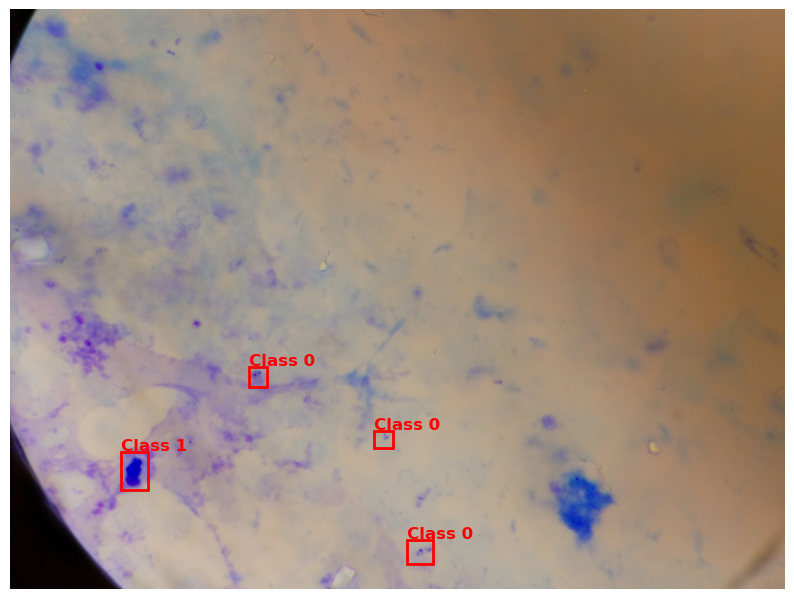

Plotting id_021o79u9zs.jpg with 16 bounding boxes.


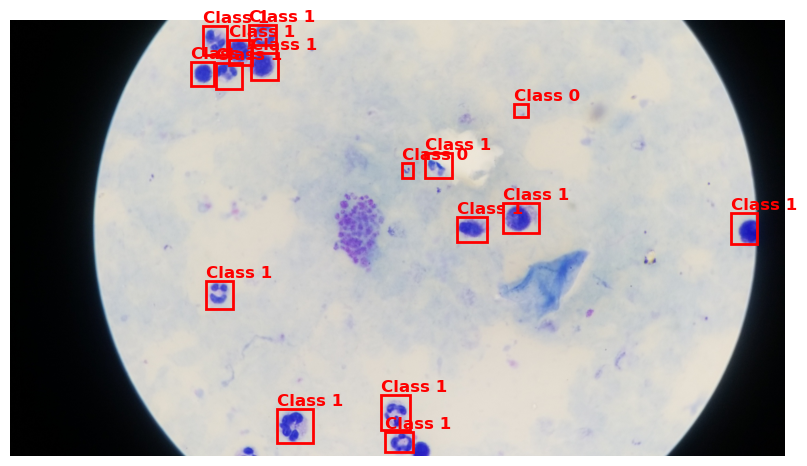

Plotting id_02q5ah1zvq.jpg with 5 bounding boxes.


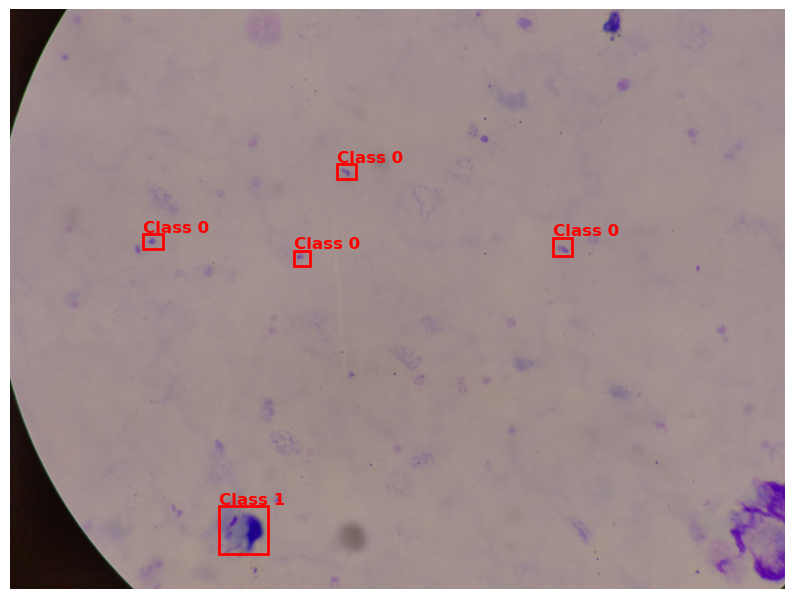

In [20]:
# Plot some images and their bboxes to ensure the conversion was done correctly
def load_annotations(label_path):
    with open(label_path, 'r') as f:
        lines = f.readlines()
    boxes = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        boxes.append((class_id, x_center, y_center, width, height))
    return boxes

# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image_path, boxes):
    # Load the image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        class_id, x_center, y_center, width, height = box
        # Convert YOLO format to corner coordinates
        xmin = int((x_center - width / 2) * w)
        ymin = int((y_center - height / 2) * h)
        xmax = int((x_center + width / 2) * w)
        ymax = int((y_center + height / 2) * h)

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

# Directories for images and labels
IMAGE_DIR = TRAIN_IMAGES_DIR
LABEL_DIR = TRAIN_LABELS_DIR

# Plot a few images with their annotations
for image_name in os.listdir(IMAGE_DIR)[:3]:
    image_path = IMAGE_DIR / image_name
    label_path = LABEL_DIR / (image_name.replace('.jpg', '.txt').replace('.png', '.txt'))

    if label_path.exists():
        boxes = load_annotations(label_path)
        print(f"Plotting {image_name} with {len(boxes)} bounding boxes.")
        plot_image_with_boxes(image_path, boxes)
    else:
        print(f"No annotations found for {image_name}.")


In [26]:
# install -u ultalytics
!pip install -U ultralytics


   ---------------------------------------- 0.0/876.6 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/876.6 kB ? eta -:--:--
   ---------------------------------------- 876.6/876.6 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.13
    Uninstalling ultralytics-8.3.13:
      Successfully uninstalled ultralytics-8.3.13


In [27]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("Cuda is Availabe")
else:
    print("Cuda Can't be found")

False
Cuda Can't be found


In [24]:
# Load a yolo pretrained model
model = YOLO('yolov8m.pt')

# Fine tune model to our data
model.train(
    data='data.yaml',          # Path to the dataset configuration
    epochs=30,                 # Number of epochs
    imgsz=2048,                # Image size (height, width)
    batch=8,                   # Batch size
    device=0,                  # Device to use (0 for the first GPU)
    patience=5)

New https://pypi.org/project/ultralytics/8.3.20 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.13  Python-3.12.7 torch-2.4.1+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: 0
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
# Validate the model on the validation set
model = YOLO('/runs/detect/train/weights/best.pt')
results = model.val()

In [ ]:
# Load the trained YOLO model
model = YOLO('/runs/detect/train/weights/best.pt')

# Path to the test images directory
test_dir_path = '/datasets/dataset/images/test'

# Get a list of all image files in the test directory
image_files = os.listdir(test_dir_path)

# Initialize an empty list to store the results for all images
all_data = []

# Iterate through each image in the directory
for image_file in tqdm(image_files):
    # Full path to the image
    img_path = os.path.join(test_dir_path, image_file)

    # Make predictions on the image
    results = model(img_path)

    # Extract bounding boxes, confidence scores, and class labels
    boxes = results[0].boxes.xyxy.tolist()  # Bounding boxes in xyxy format
    classes = results[0].boxes.cls.tolist()  # Class indices
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    names = results[0].names  # Class names dictionary

    if not boxes:
        # If no detections, add NEG as the class
        all_data.append({
            'Image_ID': image_file,
            'class': 'NEG',
            'confidence': 1.0,  # You can set this to a default value
            'ymin': 0,  # Default value (no detection)
            'xmin': 0,  # Default value (no detection)
            'ymax': 0,  # Default value (no detection)
            'xmax': 0   # Default value (no detection)
        })
    else:
        # Iterate through the results for this image
        for box, cls, conf in zip(boxes, classes, confidences):
            x1, y1, x2, y2 = box
            detected_class = names[int(cls)]  # Get the class name from the names dictionary

            # Add the result to the all_data list
            all_data.append({
                'Image_ID': image_file,
                'class': detected_class,
                'confidence': conf,
                'ymin': y1,
                'xmin': x1,
                'ymax': y2,
                'xmax': x2
            })

# Convert the list to a DataFrame for all images
sub = pd.DataFrame(all_data)

In [ ]:
sub.head()

In [ ]:
sub['class'].value_counts()

In [ ]:
# Create submission file to be uploaded to Zindi for scoring
sub.to_csv('benchmark_submission.csv', index = False)